In [1]:
import sympy as sym
import numpy as np
import matplotlib.pyplot as plt
from control import tf, step_response, poles, zeros, pzmap

# Define Laplace variable and signals
s = sym.Symbol('s')
x, y = sym.symbols('x y')

In [2]:
# Define Laplace variable and signals
s = sym.Symbol('s')
x, y = sym.symbols('x y')

In [3]:
# Given equation: 2s^2Y + sY = (s + 1)X
lhs = y * (2*s**2 + s)
rhs = x * (s + 1)

print("LHS:", lhs)
print("RHS:", rhs)

LHS: y*(2*s**2 + s)
RHS: x*(s + 1)


In [4]:
# Solve for G(s) = Y/X
G_s = sym.simplify(rhs / lhs * (y / x))

print("Transfer Function G(s):")
sym.pprint(G_s)

Transfer Function G(s):
   s + 1   
───────────
s⋅(2⋅s + 1)


In [5]:
# Extract coefficients
num = sym.Poly(sym.numer(G_s), s).all_coeffs()
den = sym.Poly(sym.denom(G_s), s).all_coeffs()

# Convert to float
num = [float(c) for c in num]
den = [float(c) for c in den]

# Create system
system = tf(num, den)

print("Numerator:", num)
print("Denominator:", den)
print("\nSystem:")
print(system)

Numerator: [1.0, 1.0]
Denominator: [2.0, 1.0, 0.0]

System:
<TransferFunction>: sys[0]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

    s + 1
  ---------
  2 s^2 + s


In [6]:
# Analyze system
p = poles(system)
z = zeros(system)

print("Poles:", p)
print("Zeros:", z)

Poles: [-0.5+0.j  0. +0.j]
Zeros: [-1.+0.j]


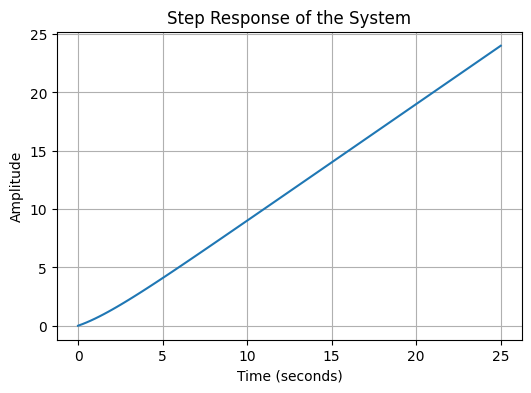

In [7]:
# Step response
time, response = step_response(system)

plt.figure(figsize=(6,4))
plt.plot(time, response)
plt.title("Step Response of the System")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.grid()
plt.show()

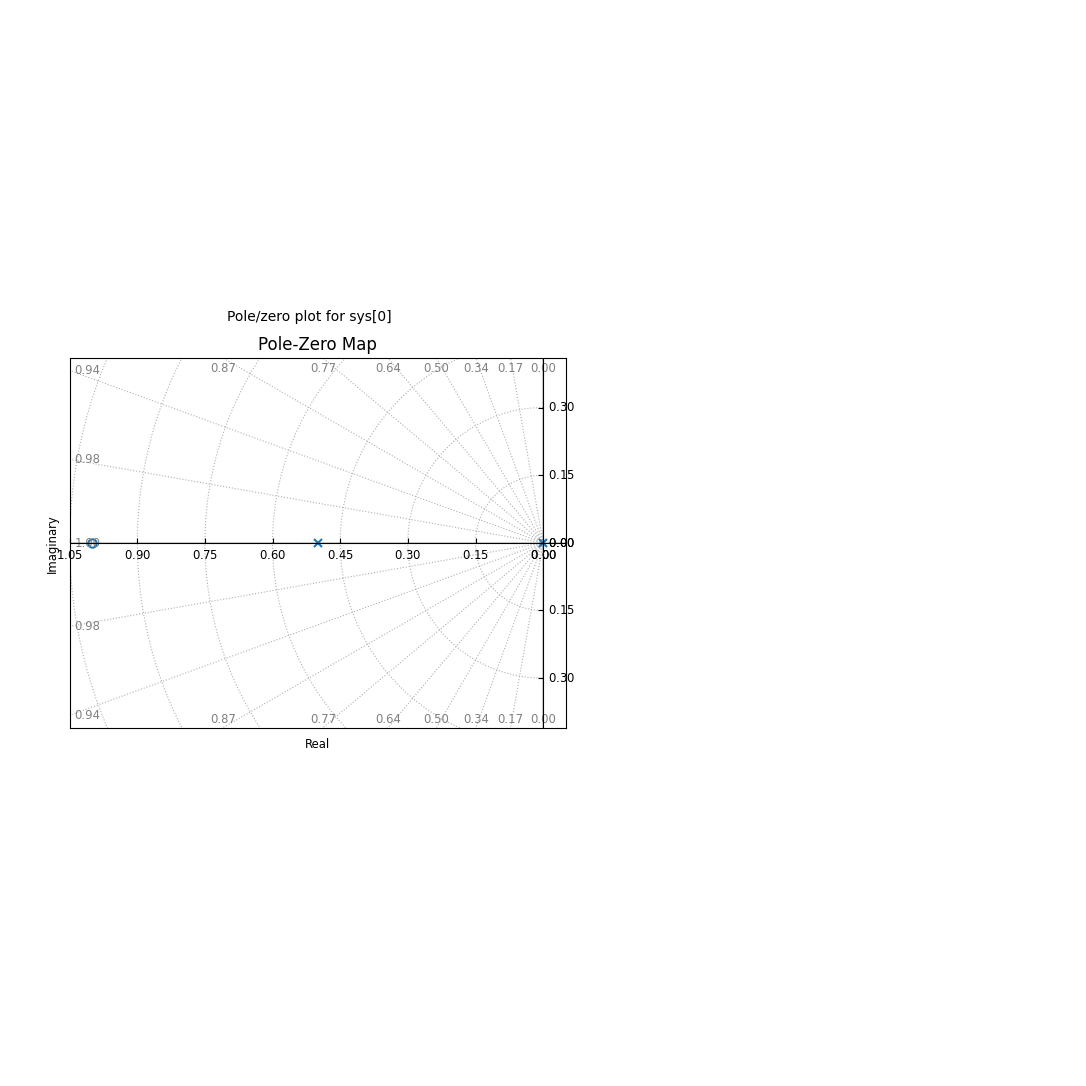

In [8]:
# Pole-zero plot
pzmap(system, grid=True)
plt.title("Pole-Zero Map")
plt.show()